In [ ]:
from typing import List, Any, Generator, Tuple
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OrdinalEncoder

## Списки

Вам дан список. Поменяйте местами первую и вторую половину списка.

In [ ]:
def swap_middle(lst: List[Any]) -> List[Any]:
    mid = len(lst) // 2
    return lst[mid:] + lst[:mid]

swap_middle([i for i in range(10)])

[5, 6, 7, 8, 9, 0, 1, 2, 3, 4]

Вам дан список. Поменяйте в нём местами блоки элементов: каждый нечётный со первого по пятый с начала с каждым чётный со второго по пятый с конца.

In [ ]:
def swap_list(lst: List[int]) -> None:
    lst[:5:2], lst[-5::2] = lst[-5::2], lst[:5:2]

lst = [i for i in range(10)]

display(lst)
swap_list(lst)
lst

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[5, 1, 7, 3, 9, 0, 6, 2, 8, 4]

## Генераторы

Вам дан список. Создайте новый список, в котором останутся только чётные элементы кратные трём.

In [ ]:
def get_multiplicity_6(lst: List[int]) -> Generator[int, None, None]:
    yield from (i for i in lst if i % 6 == 0)

lst = [i for i in range(20)]
for i in get_multiplicity_6(lst):
    print(i, end=" ")
print()

0 6 12 18 


Вам дан список. Для него и ивертированного по порядку списка выведите пары (x, y) в новом списке.

In [ ]:
def forward_backward(lst: List[int]) -> List[Tuple[int, int]]:
    for i in range(len(lst)):
        yield (lst[i], lst[-1 - i])

lst = [i for i in range(10)]
for i in forward_backward(lst):
    print(i)

(0, 9)
(1, 8)
(2, 7)
(3, 6)
(4, 5)
(5, 4)
(6, 3)
(7, 2)
(8, 1)
(9, 0)


## Встроенные функции

Вам дана строка. Выведите сумму ascii-кодов элементов в строке.

In [ ]:
def ascii_sum(text: str) -> int:
    return sum([ord(ch) for ch in text])

ascii_sum("a quick brown fox jumps over the lazy dog")

3865

Вам дана строка. Выведите строку, выведите пары (элемент строки, порядковый номер).

In [ ]:
def print_pairs(text: str) -> None:
    print(text)
    print("=" * len(text))
    for ch in text:
        print(ch, ord(ch))

print_pairs("a quick...")

a quick...
a 97
  32
q 113
u 117
i 105
c 99
k 107
. 46
. 46
. 46


## NumPy

Дан массив 16х16
Создайте новый массив 4х4 , элементы которого будут суммой блоков 4х4 исходного массива

In [ ]:
def sum_4(arr: np.ndarray[int]) -> np.ndarray[int]:
    res = np.zeros((4, 4), dtype=int)
    for i in range(1, 5):
        for j in range(1, 5):
            el = arr[
                i * 4:(i + 1) * 4,
                j * 4:(j + 1) * 4
            ].sum()
            res[i-1, j-1] = el
    return res

arr = np.random.randint(0, 10, (16, 16))
arr = sum_4(arr)
arr

array([[52, 69, 77,  0],
       [84, 54, 73,  0],
       [78, 73, 78,  0],
       [ 0,  0,  0,  0]])

Дан массив, вставьте между каждым значением сумму соседних элементов

In [ ]:
def insert_neighbors(arr: np.ndarray[int]) -> np.ndarray[int]:
    sums = arr[:-1] + arr[1:]
    positions = np.arange(1, len(arr))
    return np.insert(arr, positions, sums)

arr = np.random.randint(0, 10, (16,))
display(arr)
arr = insert_neighbors(arr)
arr

array([7, 4, 8, 7, 4, 3, 2, 1, 7, 5, 3, 0, 4, 6, 6, 2])

array([ 7, 11,  4, 12,  8, 15,  7, 11,  4,  7,  3,  5,  2,  3,  1,  8,  7,
       12,  5,  8,  3,  3,  0,  4,  4, 10,  6, 12,  6,  8,  2])

## Pandas

https://www.kaggle.com/datasets/ishadss/productivity-prediction-of-garment-employees

- Какие типы данных присутствуют в датасете?
- Есть ли в датасете пропущенные значения? Если да, то сколько и где?
- Постройте график распределения переменной `actual_productivity`.
- Постройте heatmap для матрицы корреляции числовых переменных в датасете.
- Постройте pairplot для всех переменных.
- Постройте boxplot для всех переменных и выведете объекты которые являются выбросами (строки из датафрейма).
- Посчитайте различные статестические показатели (среднее, медиана, максимум, минимум) для различных категорий в колонке `quarter` *(т.е. отдельно какие показатели у класса quarter1, какие у класса quarter2 и и т.д.)*.
- Разделите колонку `date` на три: день, месяц, год.

In [ ]:
#!/bin/bash
!curl -L -o ./productivity-prediction-of-garment-employees.zip\
  https://www.kaggle.com/api/v1/datasets/download/ishadss/productivity-prediction-of-garment-employees

!unzip ./productivity-prediction-of-garment-employees.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 16468  100 16468    0     0  40369      0 --:--:-- --:--:-- --:--:-- 40369
Archive:  ./productivity-prediction-of-garment-employees.zip
  inflating: garments_worker_productivity.csv  


In [ ]:
df = pd.read_csv("./garments_worker_productivity.csv")

# Какие типы данных присутствуют в датасете?
# Есть ли в датасете пропущенные значения? Если да, то сколько и где?

In [ ]:
df

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

В датасете присутствуют типы данных чисел (int64, float64), даты и строки (object). Некоторые категориальные данный представлены числами (колонка team)
Датасет состоит из 1197 записей, причем в колонке wip имеется 691 ненулевых значений. Все остальные колонки заполнены некоторыми значениями

In [ ]:
df.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,1197.000000,1197.000000,1197.000000,691.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000,1197.000000
mean,6.426901,0.729632,15.062172,1190.465991,4567.460317,38.210526,0.730159,0.369256,0.150376,34.609858,0.735091
std,3.463963,0.097891,10.943219,1837.455001,3348.823563,160.182643,12.709757,3.268987,0.427848,22.197687,0.174488
min,1.000000,0.070000,2.900000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.233705
25%,3.000000,0.700000,3.940000,774.500000,1440.000000,0.000000,0.000000,0.000000,0.000000,9.000000,0.650307
50%,6.000000,0.750000,15.260000,1039.000000,3960.000000,0.000000,0.000000,0.000000,0.000000,34.000000,0.773333
75%,9.000000,0.800000,24.260000,1252.500000,6960.000000,50.000000,0.000000,0.000000,0.000000,57.000000,0.850253
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,3600.000000,300.000000,45.000000,2.000000,89.000000,1.120437


# Постройте график распределения переменной `actual_productivity`

<Axes: xlabel='actual_productivity', ylabel='Count'>

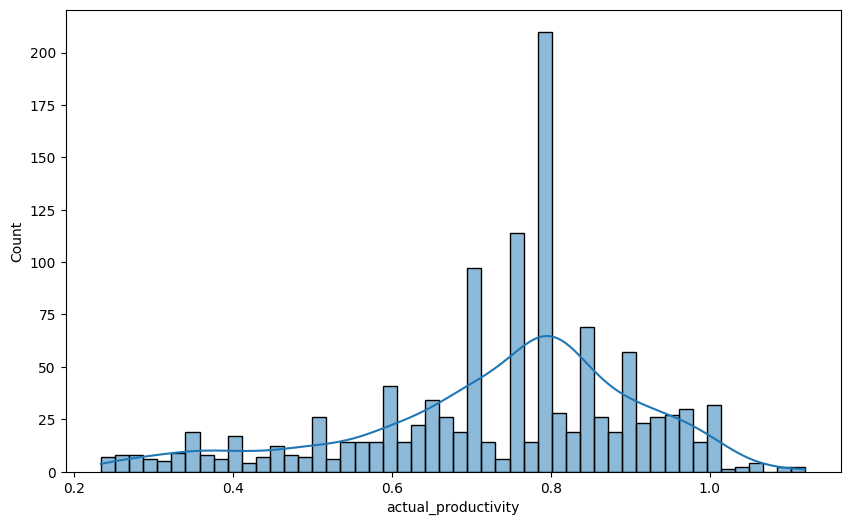

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=df,
    x="actual_productivity",
    bins=50,
    kde=True,
)

# Постройте heatmap для матрицы корреляции числовых переменных в датасете

In [ ]:
categorical_columns = ["day", "quarter", "department", "team", "no_of_style_change", "date", "wip"]
for column in categorical_columns:
    display(df[column].value_counts())

,count
day,
Wednesday,208
Sunday,203
Tuesday,201
Thursday,199
Monday,199
Saturday,187


,count
quarter,
Quarter1,360
Quarter2,335
Quarter4,248
Quarter3,210
Quarter5,44


,count
department,
sweing,691
finishing,257
finishing,249


,count
team,
8,109
2,109
4,105
1,105
9,104
10,100
12,99
7,96
3,95


,count
no_of_style_change,
0,1050
1,114
2,33


,count
date,
1/31/2015,24
3/11/2015,24
1/11/2015,23
1/24/2015,23
1/12/2015,23
3/10/2015,23
1/8/2015,22
1/13/2015,22
1/22/2015,22


,count
wip,
1039.0,5
1282.0,4
1079.0,3
1193.0,3
1069.0,3
...,...
357.0,1
817.0,1
1576.0,1


In [ ]:
heatmap_df = df
heatmap_df = heatmap_df.drop(columns=categorical_columns)
display(heatmap_df)

heatmap_df

,targeted_productivity,smv,over_time,incentive,idle_time,idle_men,no_of_workers,actual_productivity
0,0.80,26.16,7080,98,0.0,0,59.0,0.940725
1,0.75,3.94,960,0,0.0,0,8.0,0.886500
2,0.80,11.41,3660,50,0.0,0,30.5,0.800570
3,0.80,11.41,3660,50,0.0,0,30.5,0.800570
4,0.80,25.90,1920,50,0.0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...
1192,0.75,2.90,960,0,0.0,0,8.0,0.628333
1193,0.70,3.90,960,0,0.0,0,8.0,0.625625
1194,0.65,3.90,960,0,0.0,0,8.0,0.625625
1195,0.75,2.90,1800,0,0.0,0,15.0,0.505889


,targeted_productivity,smv,over_time,incentive,idle_time,idle_men,no_of_workers,actual_productivity
0,0.80,26.16,7080,98,0.0,0,59.0,0.940725
1,0.75,3.94,960,0,0.0,0,8.0,0.886500
2,0.80,11.41,3660,50,0.0,0,30.5,0.800570
3,0.80,11.41,3660,50,0.0,0,30.5,0.800570
4,0.80,25.90,1920,50,0.0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...
1192,0.75,2.90,960,0,0.0,0,8.0,0.628333
1193,0.70,3.90,960,0,0.0,0,8.0,0.625625
1194,0.65,3.90,960,0,0.0,0,8.0,0.625625
1195,0.75,2.90,1800,0,0.0,0,15.0,0.505889


<Axes: >

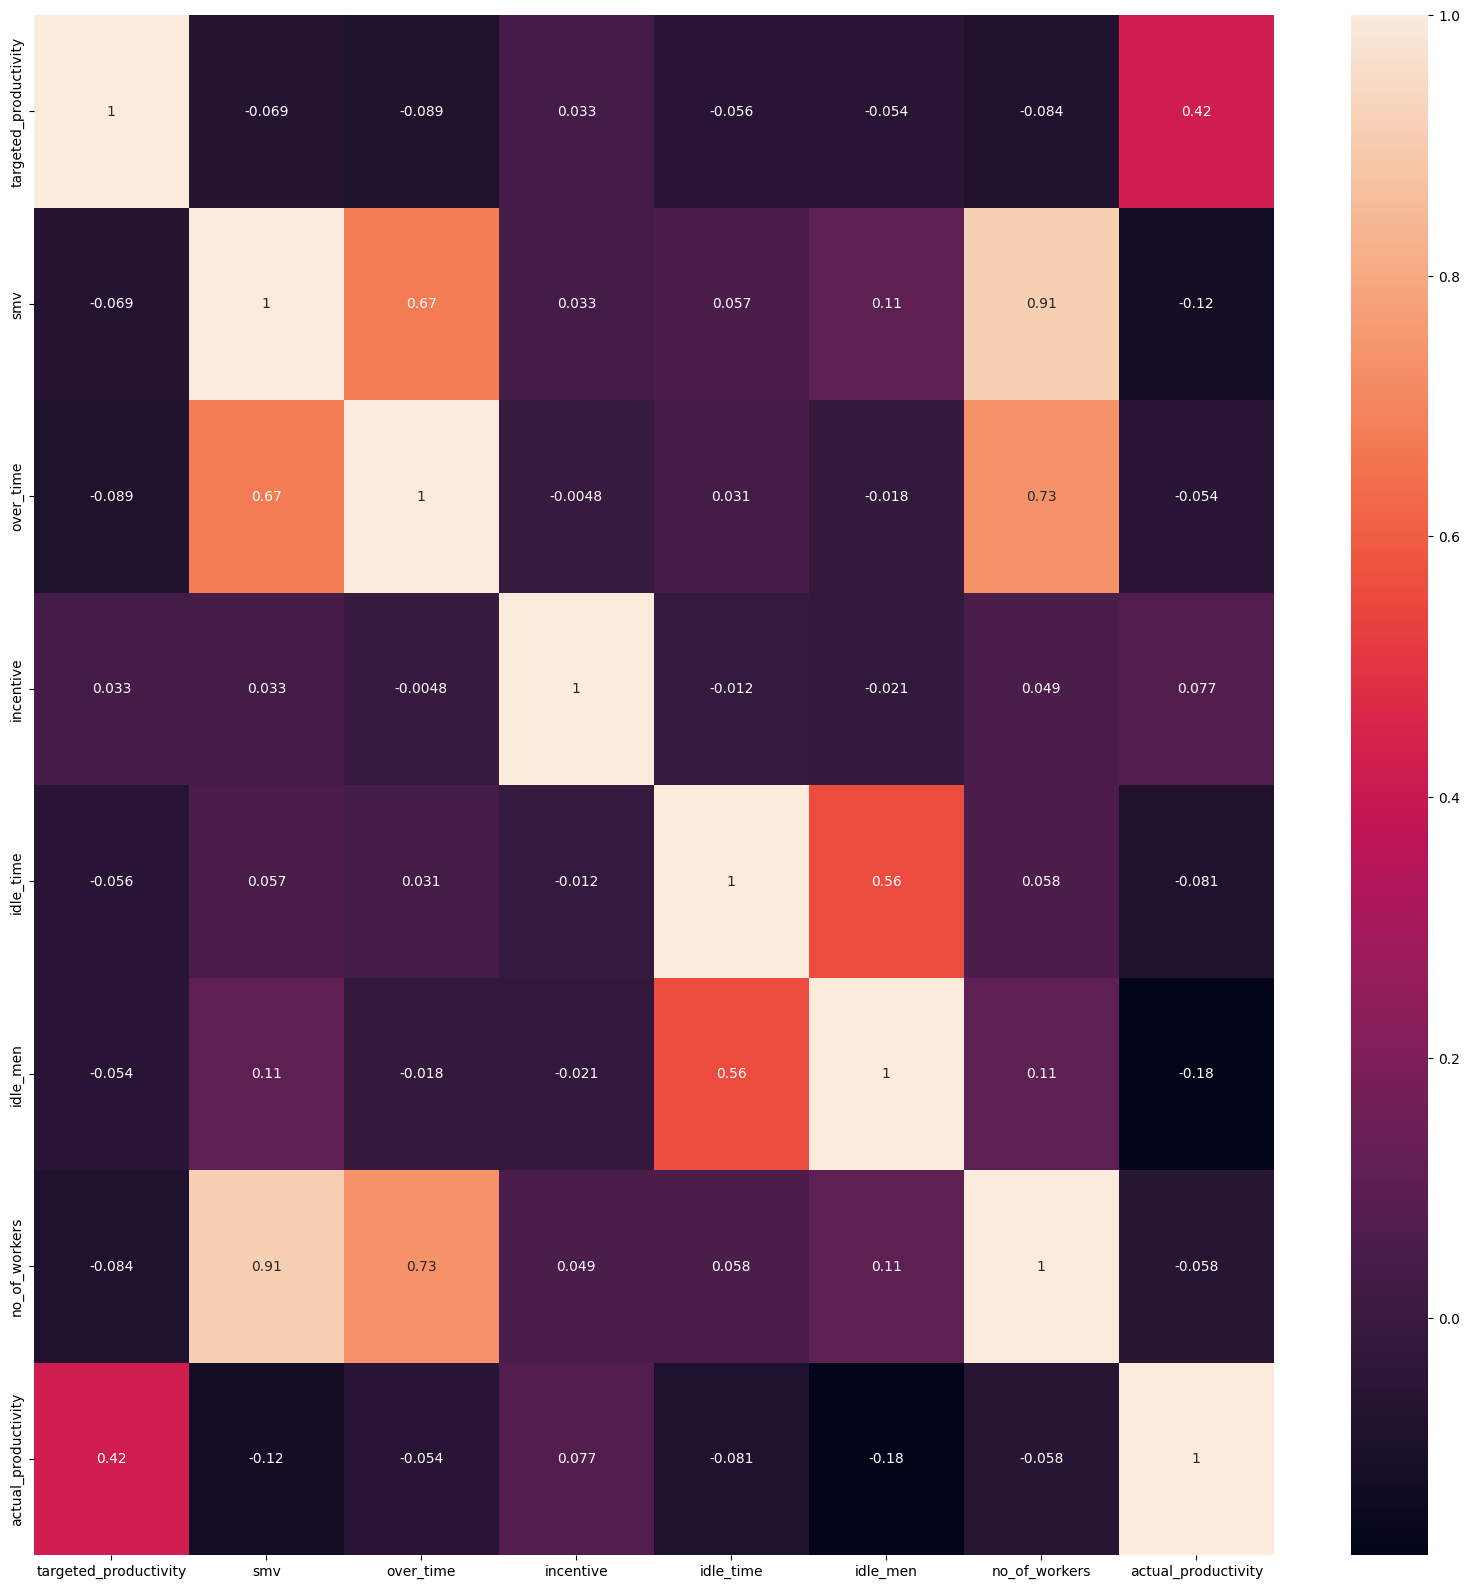

In [ ]:
plt.figure(figsize=(20, 20))
corr_matrix = heatmap_df.corr()
sns.heatmap(data=corr_matrix, annot=True)

# Постройте pairplot для всех переменных

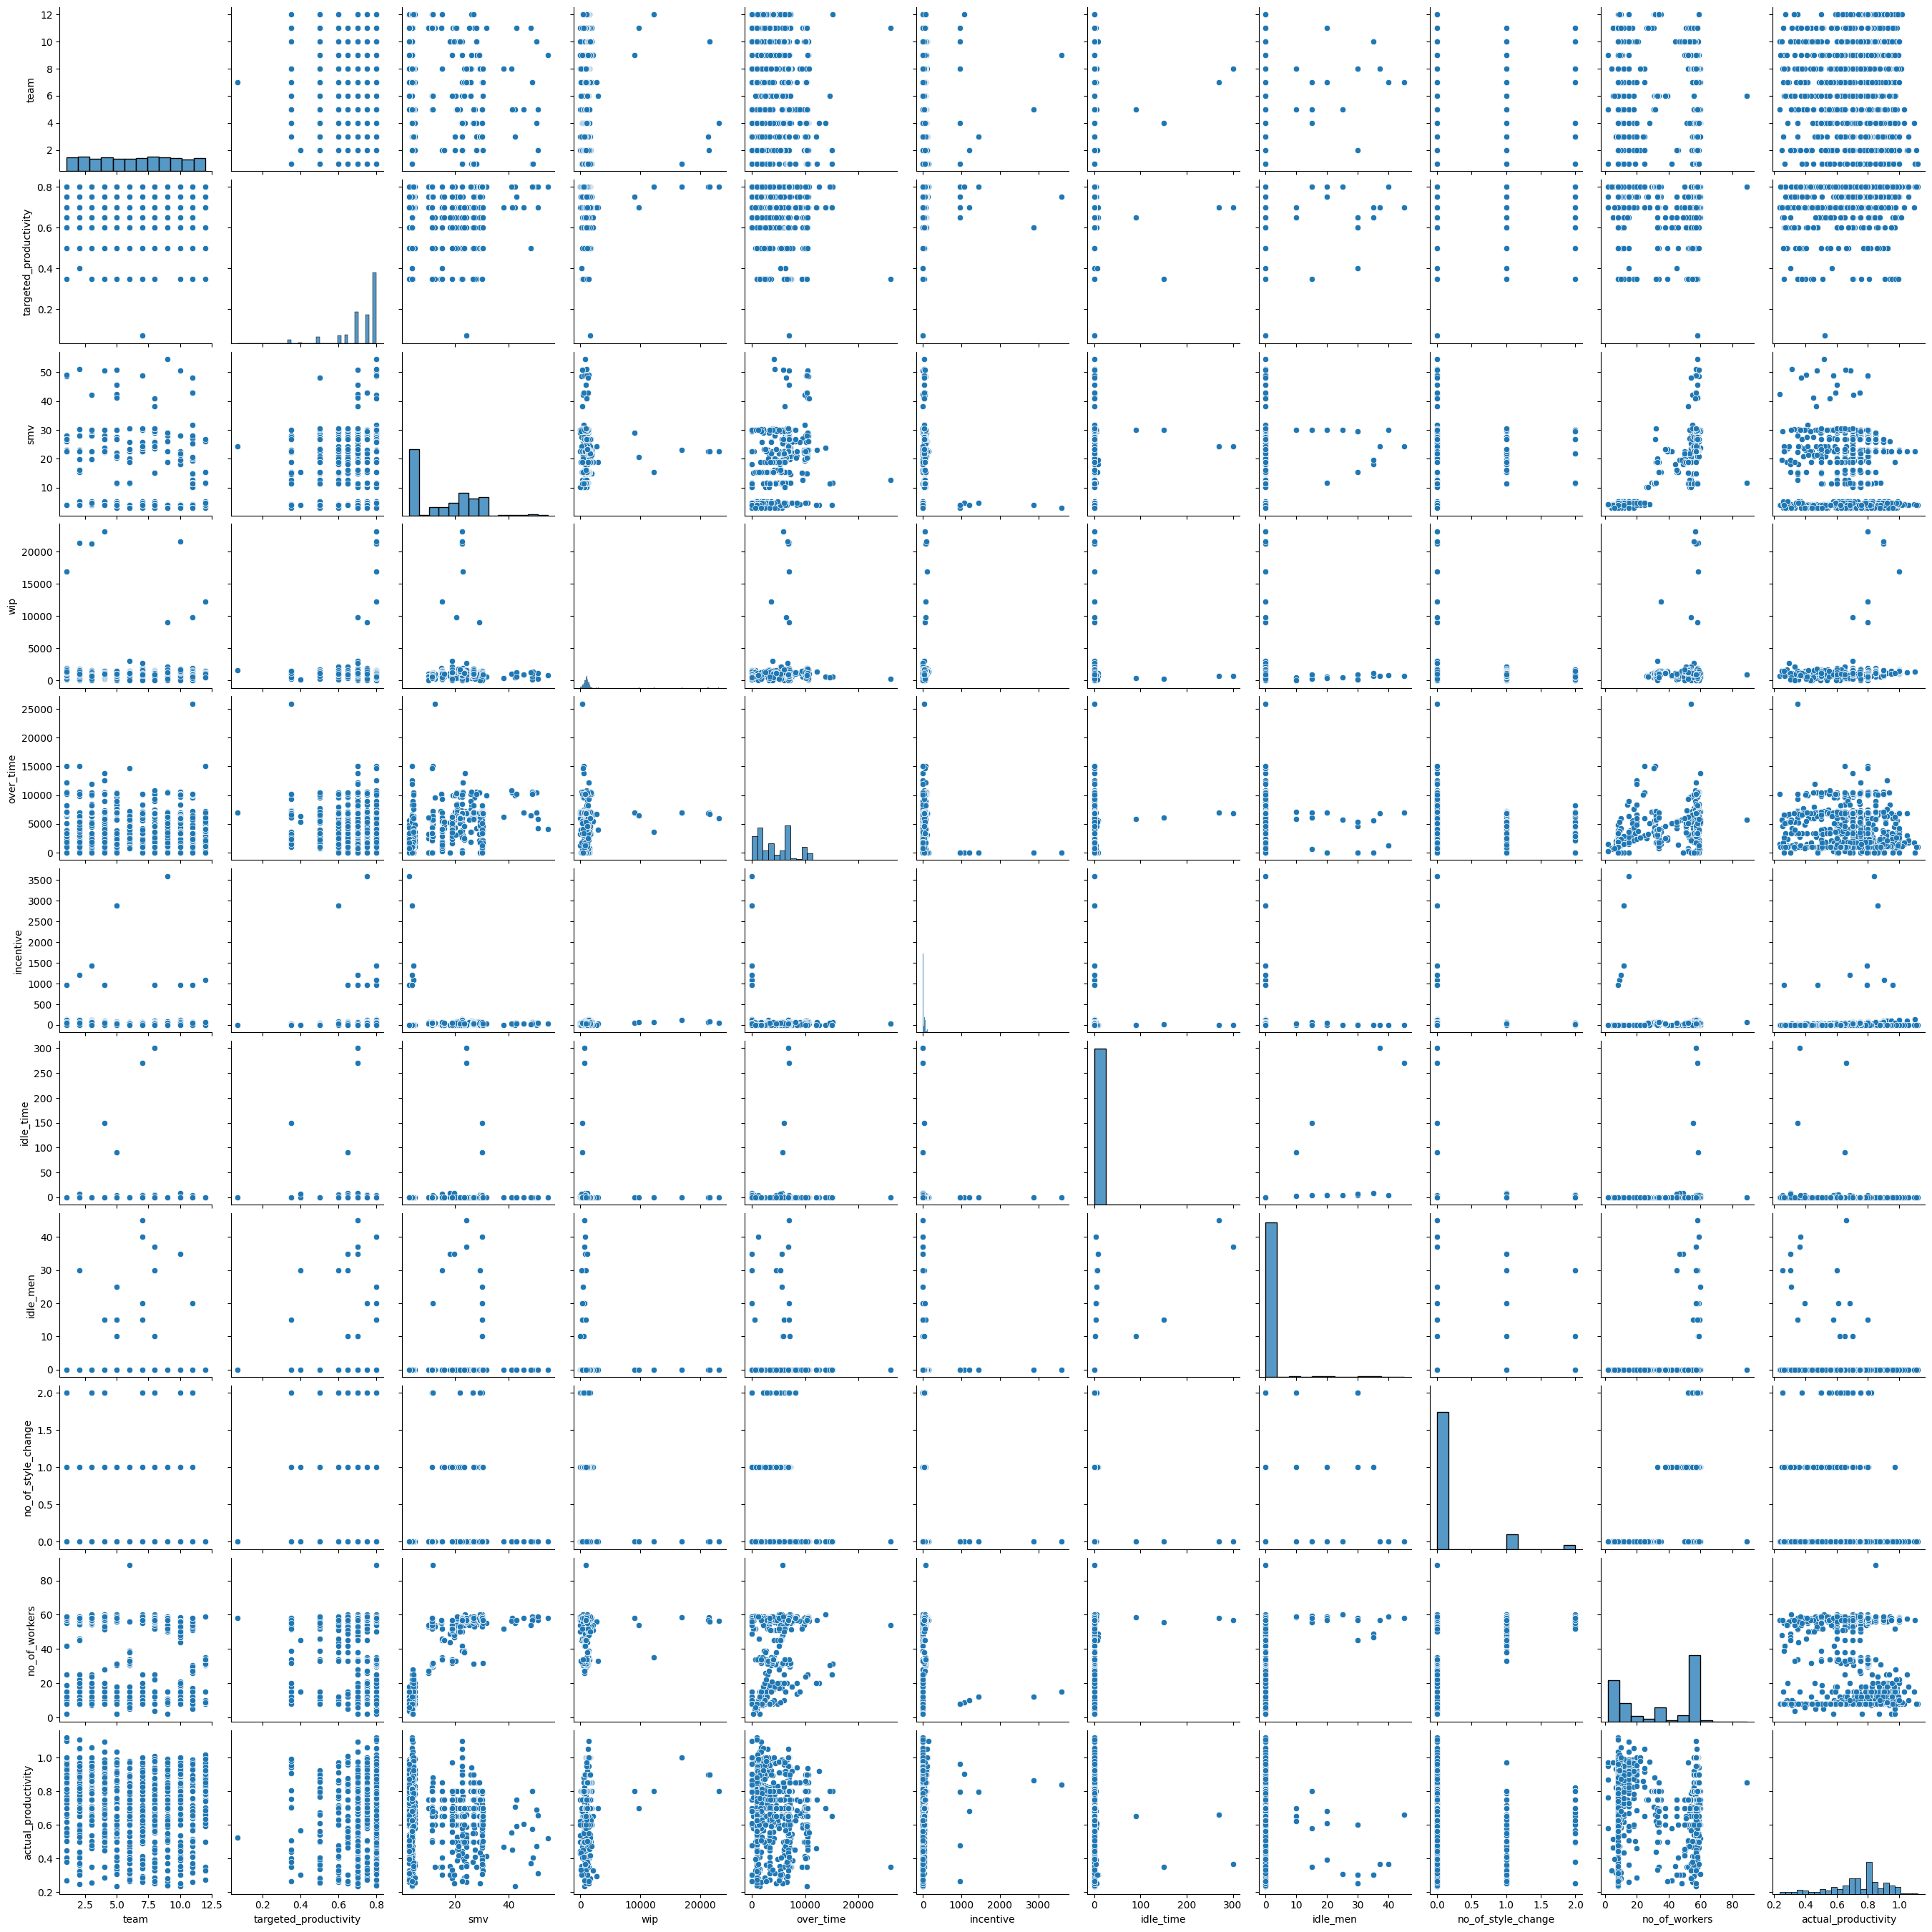

In [ ]:
sns.pairplot(df)

# Постройте boxplot для всех переменных и выведете объекты которые являются выбросами (строки из датафрейма)


Анализ выбросов для 'targeted_productivity':
Q1 (25%): 0.70
Q3 (75%): 0.80
IQR: 0.10
Границы: [0.55, 0.95]
Найдено выбросов: 79

Анализ выбросов для 'smv':
Q1 (25%): 3.94
Q3 (75%): 24.26
IQR: 20.32
Границы: [-26.54, 54.74]
Найдено выбросов: 0

Анализ выбросов для 'wip':
Q1 (25%): 774.50
Q3 (75%): 1252.50
IQR: 478.00
Границы: [57.50, 1969.50]
Найдено выбросов: 22

Анализ выбросов для 'over_time':
Q1 (25%): 1440.00
Q3 (75%): 6960.00
IQR: 5520.00
Границы: [-6840.00, 15240.00]
Найдено выбросов: 1

Анализ выбросов для 'incentive':
Q1 (25%): 0.00
Q3 (75%): 50.00
IQR: 50.00
Границы: [-75.00, 125.00]
Найдено выбросов: 11

Анализ выбросов для 'idle_time':
Q1 (25%): 0.00
Q3 (75%): 0.00
IQR: 0.00
Границы: [0.00, 0.00]
Найдено выбросов: 18

Анализ выбросов для 'idle_men':
Q1 (25%): 0.00
Q3 (75%): 0.00
IQR: 0.00
Границы: [0.00, 0.00]
Найдено выбросов: 18

Анализ выбросов для 'no_of_style_change':
Q1 (25%): 0.00
Q3 (75%): 0.00
IQR: 0.00
Границы: [0.00, 0.00]
Найдено выбросов: 147

Анализ выбросов д

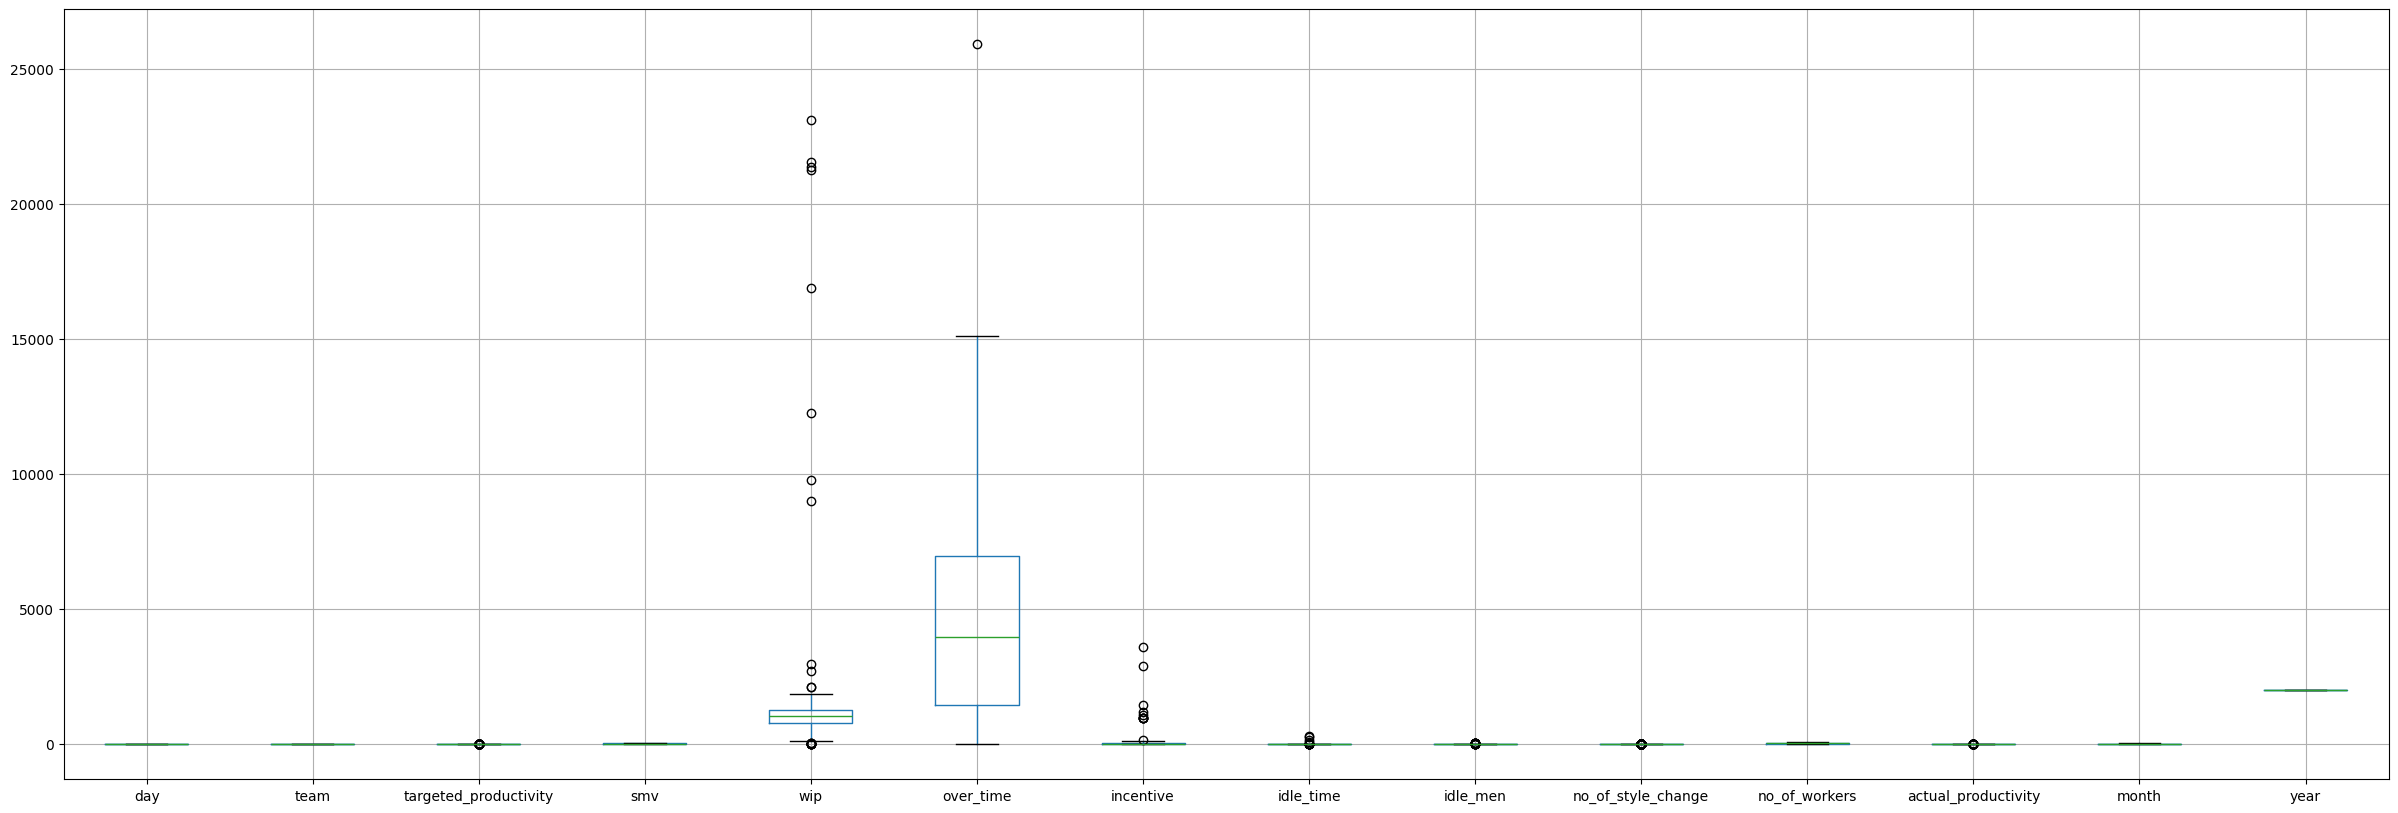

In [ ]:
plt.figure(figsize=(30, 10))
df.boxplot()

def get_outliers(df, column_name: str) -> List[int]:
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nАнализ выбросов для '{column_name}':")
    print(f"Q1 (25%): {Q1:.2f}")
    print(f"Q3 (75%): {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")

    outliers = df[column_name][(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    print(f"Найдено выбросов: {len(outliers)}")
    return outliers

for column in ["targeted_productivity",	"smv", "wip", "over_time", "incentive", "idle_time", "idle_men", "no_of_style_change", "no_of_workers", "actual_productivity"]:
    get_outliers(df, column)

# Посчитайте различные статестические показатели (среднее, медиана, максимум, минимум) для различных категорий в колонке `quarter` *(т.е. отдельно какие показатели у класса quarter1, какие у класса quarter2 и и т.д.)*

In [ ]:
numerical_cols = ["targeted_productivity",	"smv", "wip", "over_time", "incentive", "idle_time", "idle_men", "no_of_style_change", "no_of_workers", "actual_productivity"]
quarters = df.groupby("quarter").agg(dict(
    (col, ['count', 'mean', 'median', 'min', 'max', 'std']) for col in numerical_cols
)).round(2)

for col in numerical_cols:
    print("=" * 10 + "--" + col + "--" + "=" * 10)
    display(quarters[col])

==========--targeted_productivity--==========


,count,mean,median,min,max,std
quarter,,,,,,
Quarter1,360,0.74,0.80,0.07,0.8,0.09
Quarter2,335,0.73,0.80,0.35,0.8,0.11
Quarter3,210,0.72,0.75,0.35,0.8,0.10
Quarter4,248,0.71,0.75,0.35,0.8,0.09
Quarter5,44,0.72,0.75,0.50,0.8,0.09


==========--smv--==========


,count,mean,median,min,max,std
quarter,,,,,,
Quarter1,360,15.00,15.26,2.9,45.67,10.41
Quarter2,335,14.83,11.61,2.9,51.02,11.23
Quarter3,210,15.93,15.26,2.9,54.56,11.40
Quarter4,248,14.92,15.26,2.9,48.18,10.96
Quarter5,44,14.01,15.26,2.9,50.89,10.95


==========--wip--==========


...

,count,mean,median,min,max,std
quarter,,,,,,
Quarter1,360,0.03,0.0,0,1,0.16
Quarter2,335,0.14,0.0,0,2,0.36
Quarter3,210,0.22,0.0,0,2,0.51
Quarter4,248,0.31,0.0,0,2,0.63
Quarter5,44,0.00,0.0,0,0,0.00


==========--no_of_workers--==========


,count,mean,median,min,max,std
quarter,,,,,,
Quarter1,360,34.84,34.0,8.0,60.0,21.94
Quarter2,335,33.74,34.0,2.0,60.0,22.51
Quarter3,210,36.44,48.5,2.0,89.0,22.40
Quarter4,248,34.43,34.0,4.0,60.0,21.85
Quarter5,44,31.66,33.0,2.0,59.0,23.21


==========--actual_productivity--==========


,count,mean,median,min,max,std
quarter,,,,,,
Quarter1,360,0.75,0.80,0.26,1.05,0.16
Quarter2,335,0.74,0.80,0.23,1.10,0.17
Quarter3,210,0.70,0.73,0.24,1.12,0.18
Quarter4,248,0.71,0.75,0.26,1.06,0.19
Quarter5,44,0.83,0.89,0.29,1.00,0.18


# Разделите колонку `date` на три: день, месяц, год

In [ ]:
df[['day', 'month', 'year']] = df['date'].str.split('/', expand=True).astype(int)
df[['day', 'month', 'year']]

,day,month,year
0,1,1,2015
1,1,1,2015
2,1,1,2015
3,1,1,2015
4,1,1,2015
...,...,...,...
1192,3,11,2015
1193,3,11,2015
1194,3,11,2015
1195,3,11,2015
